In [1]:
import numpy as np
from microlensing import Microlensing
from utils import ParamRange
from consts import *

In [2]:
event_url = "https://www.astrouw.edu.pl/ogle/ogle4/ews/2019/blg-0035"
ms_event = Microlensing(event_url)

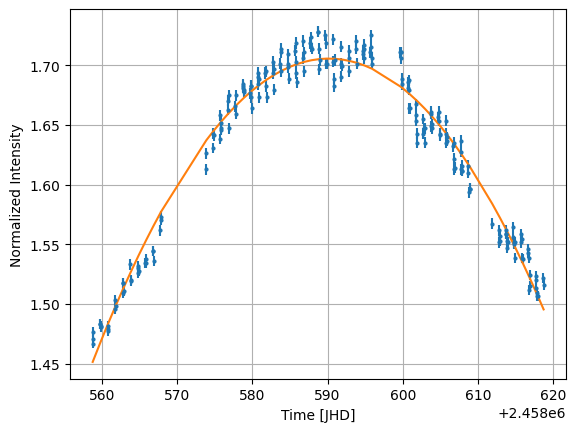

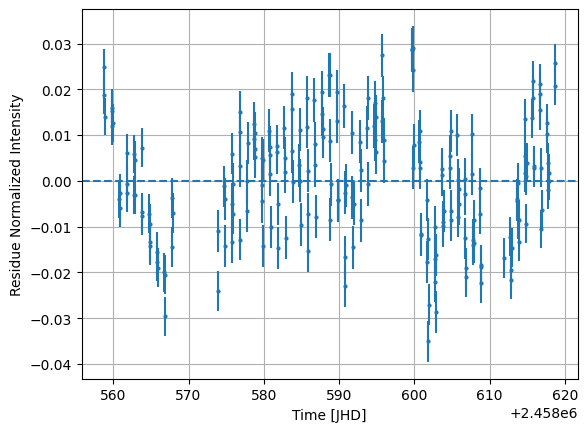

Chi: 8.232299366155976

nsigma with ogle params:
t0_ogle: 2458590.330±0.026
t0_par: 2458590.167±0.178
nsigma: 0.9011629893998434

Imax_ogle: 1.717±0.000
Imax_par: 1.7056±0.0025
nsigma: 4.597770602005301

umin_ogle: 0.679±0.000
umin_par: 0.6847±0.0014
nsigma: 4.174290988597695


{'t0': t0_par: 2458590.167±0.178,
 'Imax': Imax_par: 1.7056±0.0025,
 'umin': umin_par: 0.6847±0.0014}

In [3]:
# Apply linear parabolic fit for initial param guess
mid_range=ms_event.data["JHD"][np.argmax(ms_event.data[I_VAL])]
range_len=30
ms_event.parabolic_fit(mid_range, range_len)

In [4]:
# Use linear parabolic fit params for initial param guess

u_min_par = ms_event.par_params[U_MIN]
t0_par = ms_event.par_params[T0]
std_range = 10

u_min_range = ParamRange(U_MIN, u_min_par.value - u_min_par.lower_error*std_range, u_min_par.value + u_min_par.upper_error*std_range)
t0_range = ParamRange(T0, t0_par.value - t0_par.lower_error*std_range, t0_par.value + t0_par.upper_error*std_range)

params_range = [u_min_range, t0_range]
fixed_params = {TAU: ms_event.ogle[TAU].value, F_BL: ms_event.ogle[F_BL].value}

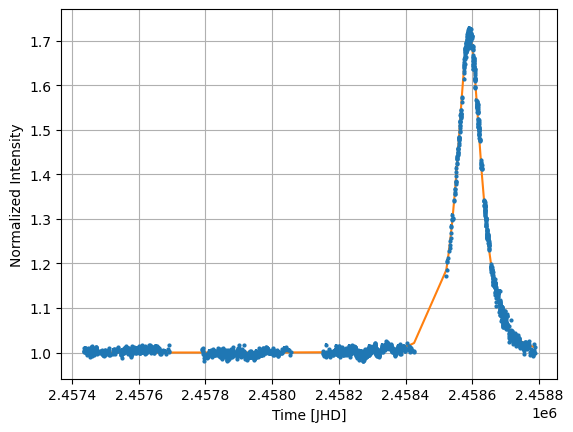

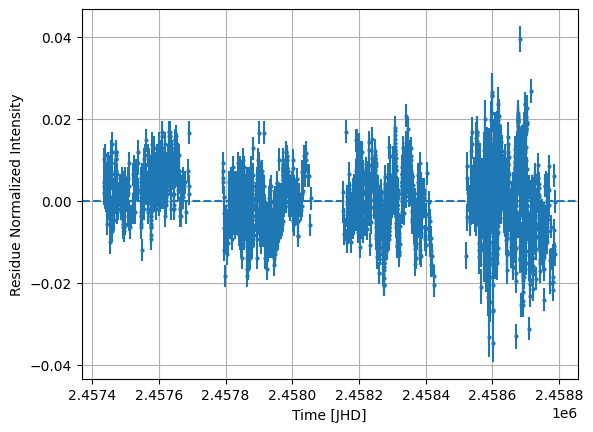

Chi: 19114.137447606936 (Chi Reduced: 6.9556540930156245)

--- nsigma with ogle params ---
umin_ogle: 0.679±0.000
umin_non_linear_2_params: 0.67900[-0.00020,+0.00013]
nsigma: 0.012481182576648835

t0_ogle: 2458590.330±0.026
t0_non_linear_2_params: 2458590.303[-0.021,+0.022]
nsigma: 0.8053505691964208

--- nsigma with parabolic params ---
umin_par: 0.6847±0.0014
umin_non_linear_2_params: 0.67900[-0.00020,+0.00013]
nsigma: 4.154732142887646

t0_par: 2458590.167±0.178
t0_non_linear_2_params: 2458590.303[-0.021,+0.022]
nsigma: 0.7521265190034662



{'umin': umin_non_linear_2_params: 0.67900[-0.00020,+0.00013],
 't0': t0_non_linear_2_params: 2458590.303[-0.021,+0.022]}

In [5]:
ms_event.non_linear_fit(params_range, fixed_params)

t0 vs. umin effect on Goodness of Fit (chi)


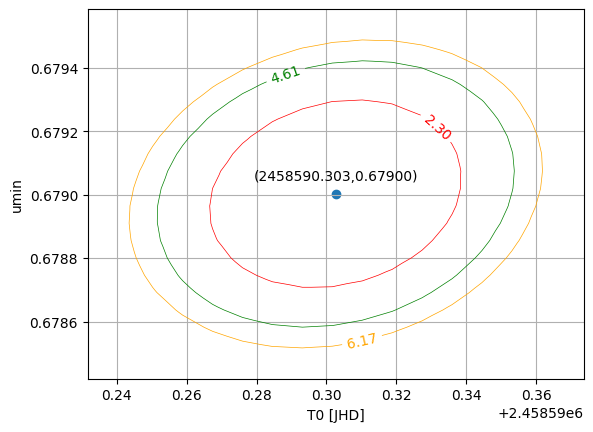

In [6]:

ms_event.non_linear_contours([T0, U_MIN], fixed_params)

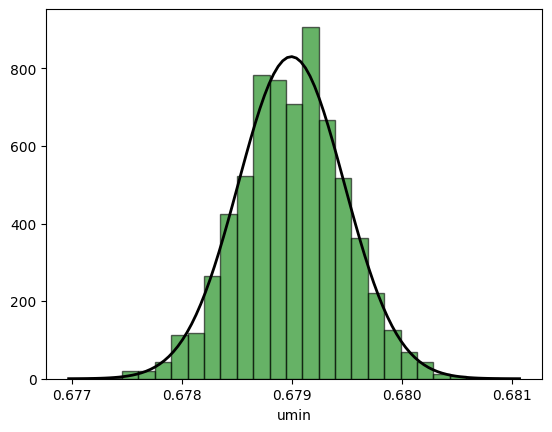

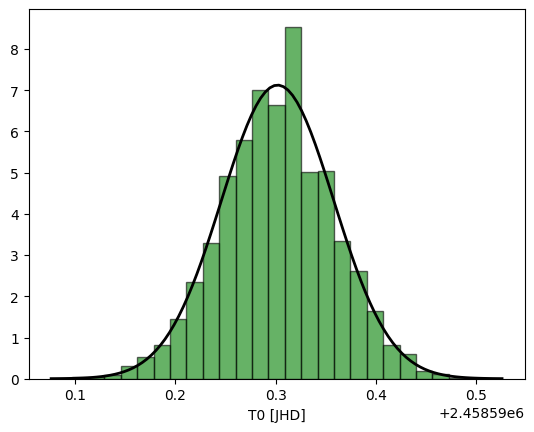

bootstrap:
umin_non_linear_2_params: 0.67900[-0.00020,+0.00013]
umin_hist: 0.67899±0.00048
bootstrap value comparison: 0.06492976559228415
bootstrap error comparison: fit error order e-4, bootstrap error order e-4

t0_non_linear_2_params: 2458590.303[-0.021,+0.022]
t0_hist: 2458590.302±0.056
bootstrap value comparison: 0.030223554058036273
bootstrap error comparison: fit error order e-2, bootstrap error order e-2



In [8]:
for param in params_range:
    param.n_segments = 5
ms_event.non_lin_bootstrap(init_params=params_range, fixed_params=fixed_params, iter=10000)